# ECG R-Peak Detection using Deep Learning

This project detects R-peaks in ECG signal using MIT-BIH dataset.
Peak detection is performed using deep learning model implemented in PyTorch.

## Introduction

Electrocardiogram (ECG) is a signal representing electrical activity of the heart.

R-peak detection is important for:

- Heart rate calculation
- Arrhythmia detection
- Medical diagnosis
- Signal analysis

This project detects R-peaks using machine learning.

## ECG Signal

ECG waveform contains:

P wave
QRS complex
T wave

R peak is the highest point in QRS complex.
R-peaks are used to calculate heart rate.

## Dataset

We use MIT-BIH Arrhythmia dataset.

Dataset is loaded using WFDB library.

Record 100 is used for testing.

In [2]:
import wfdb
import os
import time

data_path = "data"

os.makedirs(data_path, exist_ok=True)

records = [
    "100","101","102","103","104","105","106","107","108","109",
    "111","112","113","114","115","116","117","118","119",
    "121","122","123","124",
    "200","201","202","203","205","207","208","209","210",
    "212","213","214","215","217","219","220","221","222",
    "223","228","230","231","232","233","234"
]

for r in records:

    try:
        print("Downloading", r)

        wfdb.dl_database(
            "mitdb",
            dl_dir=data_path,
            records=[r]
        )

        time.sleep(1)   # slow download → avoid error

    except Exception as e:
        print("Error on", r, e)

print("Download finished")


Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 102
Generating list of all files for: 102
Finished downloading files
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Generating record list for: 104
Generating list of all files for: 104
Finished downloading files
Generating record list for: 105
Generating list of all files for: 105
Finished downloading files
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
Generating record list for: 107
Generating list of all files for: 107
Finished downloading files
Generating record list for: 108
Generating list of all files for: 108
Finished downloading files
Generating record list for: 109
Generating list of all files for: 109
Finished downloading files
Generating record list for: 11

## Import Libraries

Required libraries are imported for ECG signal processing.

- wfdb → used to read MIT-BIH ECG dataset
- os → used to access files in folder
- numpy → used for numerical operations
- matplotlib → used for plotting ECG signal

In [7]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt

## Checking Dataset Files

The ECG dataset is stored in the data folder.

Each record contains:

- .dat → signal data
- .hea → header file
- .atr → annotation file (R-peaks)

We list files to verify dataset is loaded correctly.

In [5]:
import os
print(os.listdir("data"))

['100.atr', '100.dat', '100.hea', '101.atr', '101.dat', '101.hea', '102.atr', '102.dat', '102.hea', '103.atr', '103.dat', '103.hea', '104.atr', '104.dat', '104.hea', '105.atr', '105.dat', '105.hea', '106.atr', '106.dat', '106.hea', '107.atr', '107.dat', '107.hea', '108.atr', '108.dat', '108.hea', '109.atr', '109.dat', '109.hea', '111.atr', '111.dat', '111.hea', '112.atr', '112.dat', '112.hea', '113.atr', '113.dat', '113.hea', '114.atr', '114.dat', '114.hea', '115.atr', '115.dat', '115.hea', '116.atr', '116.dat', '116.hea', '117.atr', '117.dat', '117.hea', '118.atr', '118.dat', '118.hea', '119.atr', '119.dat', '119.hea', '121.atr', '121.dat', '121.hea', '122.atr', '122.dat', '122.hea', '123.atr', '123.dat', '123.hea', '124.atr', '124.dat', '124.hea', '200.atr', '200.dat', '200.hea', '201.atr', '201.dat', '201.hea', '202.atr', '202.dat', '202.hea', '203.atr', '203.dat', '203.hea', '205.atr', '205.dat', '205.hea', '207.atr', '207.dat', '207.hea', '208.atr', '208.dat', '208.hea', '209.atr'

## Method

Steps:

1. Load ECG signal
2. Load annotation
3. Detect peaks
4. Compare with true peaks
5. Plot results
6. Zoom peaks

## Loading ECG Signal

The ECG signal is loaded from the MIT-BIH Arrhythmia dataset using the WFDB library.

Steps performed:

- Read ECG record using `rdrecord`
- Read annotation using `rdann`
- Extract ECG signal from channel 0
- Annotation file contains true R-peak locations

Record 100 from the dataset is used for analysis.

In [17]:

data_path = "data"
record = wfdb.rdrecord(os.path.join(data_path, "100"))
ann = wfdb.rdann(os.path.join(data_path, "100"), "atr")

signal = record.p_signal[:,0]

print(len(signal))

650000


## ECG Signal Visualization

After loading the ECG record, the signal is extracted from the first channel.

The total number of samples in the signal is printed to verify
that the data is loaded correctly.

A small portion of the signal (first 1000 samples) is plotted
to visualize the ECG waveform.

Visualization helps to observe the QRS complex
and locate R-peak positions.

Signal length: 650000


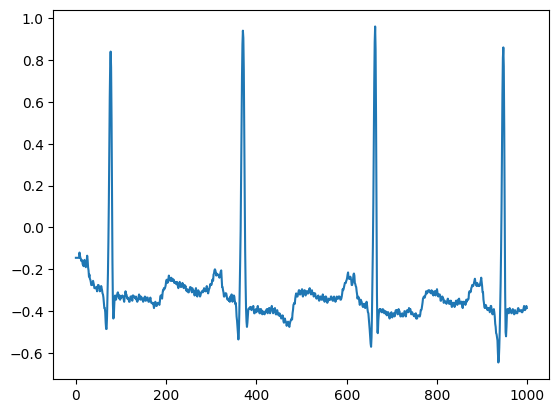

In [18]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt

data_path = "data"


record = wfdb.rdrecord(os.path.join(data_path, "100"))
ann = wfdb.rdann(os.path.join(data_path, "100"), "atr")

signal = record.p_signal[:,0]

print("Signal length:", len(signal))

plt.plot(signal[:1000])
plt.show()

## ECG Signal Normalization

Before peak detection, the ECG signal is normalized.

Normalization formula:

(signal − mean) / standard deviation:

Purpose of normalization:

- Removes signal offset
- Scales values to standard range
- Improves numerical stability
- Helps machine learning model training

The normalized ECG waveform is plotted for visualization.

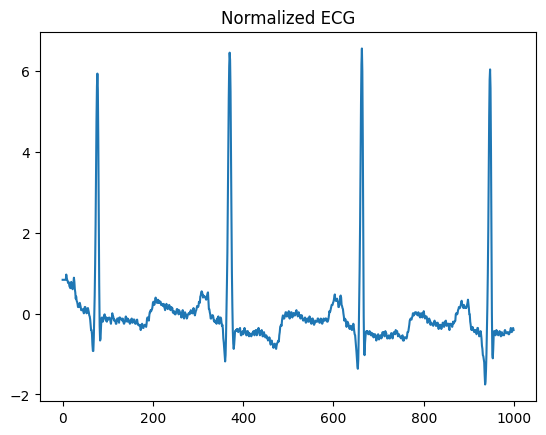

In [19]:
signal = (signal - np.mean(signal)) / np.std(signal)

plt.plot(signal[:1000])
plt.title("Normalized ECG")
plt.show()

## Window Size

The ECG signal is divided into fixed-length windows.

Window size = 200 samples.

Each window represents a small portion of ECG
and will be used for peak classification.

In [20]:
window_size = 200

## R-Peak Annotation

True R-peak positions are obtained
from the annotation file (.atr).

These peaks are used as ground truth
for training the model.

In [21]:
ann = wfdb.rdann(os.path.join(data_path, "100"), "atr")

r_peaks = ann.sample

print(r_peaks[:10])

[  18   77  370  662  946 1231 1515 1809 2044 2402]


## Label Generation

Each ECG window is checked for R-peak.

If the window contains R-peak → label = 1  
If no peak → label = 0

This creates training data for the model.

Input → ECG window  
Output → Peak / No Peak

In [22]:
labels = []

for i in range(0, len(signal) - window_size, window_size):

    start = i
    end = i + window_size

    if any((r_peaks >= start) & (r_peaks < end)):
        labels.append(1)
    else:
        labels.append(0)

print(len(labels))

3249


## Window Generation

The normalized ECG signal is divided into
fixed-length windows.

Window size = 200 samples.

Each window represents a small ECG segment
used for training the model.

In [23]:
windows = []

for i in range(0, len(signal) - window_size, window_size):

    w = signal[i:i+window_size]
    windows.append(w)

print(len(windows))

3249


## Dataset Preparation

Input windows and labels are converted
into numpy arrays.

X shape = (samples, window_size)  
y shape = (samples)

This dataset will be used for training.

In [24]:
import numpy as np

X = np.array(windows)
y = np.array(labels)

print(X.shape)
print(y.shape)

(3249, 200)
(3249,)


## Tensor Conversion

The dataset is converted to PyTorch tensors.

X_tensor → input data  
y_tensor → labels

Tensor format is required for
deep learning model training.

In [25]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([3249, 200])
torch.Size([3249])


## Tensor Reshaping for CNN

Conv1D requires input shape:

(batch_size, channels, signal_length)

Unsqueeze is used to add channel dimension.

Example shape:
(3249, 1, 200)

In [26]:
X_tensor = X_tensor.unsqueeze(1)

print(X_tensor.shape)

torch.Size([3249, 1, 200])


## Dataset and DataLoader

TensorDataset combines input and labels.

DataLoader is used to:

- Load data in batches
- Shuffle data
- Improve training speed

Batch size = 32

In [27]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, y_tensor)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(loader))

102


## CNN Model for R-Peak Detection

A 1D Convolutional Neural Network is used.

Layers:

- Conv1D → feature extraction
- ReLU → activation
- Linear → classification

Input = ECG window  
Output = Peak / No Peak

In [28]:
import torch.nn as nn

class ECGModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 16, 3)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(16*198, 1)

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)

        x = x.view(x.size(0), -1)

        x = self.fc(x)

        return x


model = ECGModel()

print(model)

ECGModel(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (fc): Linear(in_features=3168, out_features=1, bias=True)
)


## Loss Function

Binary Cross Entropy with Logits is used.

This loss is suitable for
peak / no peak classification.

It improves numerical stability
during training.

In [29]:
loss_fn = nn.BCEWithLogitsLoss()


## Optimizer

Adam optimizer is used to train the model.

It updates parameters using gradients.

Learning rate = 0.001

In [30]:
import torch

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Model Training

The CNN model is trained for 100 epochs.

For each batch:

Forward pass → prediction  
Loss calculation  
Backward pass → gradients  
Optimizer step → update weights

Loss is stored to plot training curve.

In [80]:
loss_list = []

for epoch in range(100):

    total_loss = 0

    for xb, yb in loader:

        xb = xb.float()
        yb = yb.float()

        # correct forward pass
        pred = model(xb).squeeze()

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loss_list.append(loss.item())

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 0.6297667365696353
Epoch: 1 Loss: 1.661309057784656
Epoch: 2 Loss: 0.02565264311700266
Epoch: 3 Loss: 0.005616331118738848
Epoch: 4 Loss: 0.0032980599939865587
Epoch: 5 Loss: 0.002896518579440289
Epoch: 6 Loss: 0.0026381357803134968
Epoch: 7 Loss: 0.0024297608029218744
Epoch: 8 Loss: 0.0022250612111288006
Epoch: 9 Loss: 0.0021681425694646626
Epoch: 10 Loss: 0.0020342662725574617
Epoch: 11 Loss: 0.001908230759678024
Epoch: 12 Loss: 0.0018524606396853353
Epoch: 13 Loss: 0.0017344752229439975
Epoch: 14 Loss: 0.0017104905692185601
Epoch: 15 Loss: 0.001600988049980493
Epoch: 16 Loss: 0.001878231651610808
Epoch: 17 Loss: 0.001459736384022841
Epoch: 18 Loss: 0.0014771616126684865
Epoch: 19 Loss: 0.0013647308587694533
Epoch: 20 Loss: 0.0013348632672875215
Epoch: 21 Loss: 0.0012935049816258579
Epoch: 22 Loss: 0.001286902824268743
Epoch: 23 Loss: 0.0012170112625619935
Epoch: 24 Loss: 0.001144046643027774
Epoch: 25 Loss: 0.001159754910064632
Epoch: 26 Loss: 0.001121250188864012
Epo

## Model Accuracy


## Model Evaluation

The trained CNN model is evaluated
using classification accuracy.

Sigmoid activation converts output to probability.
Threshold = 0.5 is used for binary decision.

Prediction = 1 → R-peak  
Prediction = 0 → No peak

Accuracy = correct / total

In [81]:
correct = 0
total = 0

with torch.no_grad():

    for xb, yb in loader:

        pred = model(xb).squeeze()
        pred = torch.sigmoid(pred)

        pred = pred > 0.5

        correct += (pred == yb).sum().item()
        total += len(yb)

accuracy = correct / total

print("Accuracy:", accuracy)

Accuracy: 1.0


## Train-Test Split

To evaluate model performance,
the dataset is divided into training
and testing sets.

train_test_split is used with:

test_size = 0.2  
random_state = 42

Training data → model learning  
Testing data → model evaluation

This ensures reliable accuracy.

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tensor,
    y_tensor,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


torch.Size([2599, 200])
torch.Size([650, 200])


## Creating Train and Test Loaders

After splitting the data, we create `train_loader` and `test_loader`. The train loader is used during model training, while the test loader will be used later for evaluation. The batch size is set to 32 for both.

In [59]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Training Phase

The CNN model is trained using the training dataset.

train_loader provides batches of data.

For each epoch:
- Forward pass → prediction
- Loss calculation → BCEWithLogitsLoss
- Backward pass → gradients
- Optimizer step → update parameters

Loss per epoch is displayed
to verify that the model is learning.

In [82]:
for epoch in range(100):

    total_loss = 0

    for xb, yb in train_loader:

        pred = model(xb.float().unsqueeze(1)).squeeze()

        loss = loss_fn(pred, yb.float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch", epoch, total_loss)

Epoch 0 0.0016340781886921903
Epoch 1 0.0015642209896923713
Epoch 2 0.001470679293715056
Epoch 3 0.0013266659835151024
Epoch 4 0.0012441234287021462
Epoch 5 0.001217056404624914
Epoch 6 0.0011664121791635262
Epoch 7 0.0011177286854107272
Epoch 8 0.0010286175652185867
Epoch 9 0.0009932765563833183
Epoch 10 0.0009475628275931334
Epoch 11 0.0009212118255538399
Epoch 12 0.0008705593978962278
Epoch 13 0.000865059886390456
Epoch 14 0.0008039495535367323
Epoch 15 0.0007834638920251374
Epoch 16 0.0007783109881404988
Epoch 17 0.0007243985034682647
Epoch 18 0.0007057776934681207
Epoch 19 0.0006994455579225182
Epoch 20 0.0006531710377590712
Epoch 21 0.0006482640752335938
Epoch 22 0.0006280725043267634
Epoch 23 0.0006022197288572719
Epoch 24 0.0005902921236388993
Epoch 25 0.0005887683858608152
Epoch 26 0.0005591119127873589
Epoch 27 0.000545549698467546
Epoch 28 0.0005295186116475323
Epoch 29 0.0005125881980203977
Epoch 30 0.0005069455421419117
Epoch 31 0.0005085925244368352
Epoch 32 0.00048992622

## Model Evaluation on Test Data

The model is evaluated using the test dataset.

Training data is not used here,
so this gives unbiased accuracy.

Sigmoid converts logits to probability.

Prediction > 0.5 → Peak  
Prediction ≤ 0.5 → No peak

Accuracy = correct / total

#### Result

The model achieved high accuracy
on the test dataset.

This shows the model can correctly
detect R-peaks in ECG signal.


In [63]:
correct = 0
total = 0

with torch.no_grad():

    for xb, yb in test_loader:

        pred = model(xb.float().unsqueeze(1)).squeeze()
        pred = torch.sigmoid(pred)
        pred = pred > 0.5

        correct += (pred == yb).sum().item()
        total += len(yb)

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9984615384615385


## Training Accuracy Evaluation

The model performance is checked
using the training dataset.

Predictions are compared with true labels.

Accuracy close to 1 indicates
the model has learned the training data.

Very high accuracy may indicate overfitting.

In [66]:
correct = 0
total = 0

with torch.no_grad():

    for xb, yb in train_loader:

        pred = model(xb.float().unsqueeze(1)).squeeze()
        pred = torch.sigmoid(pred)

        pred = pred > 0.5

        correct += (pred == yb).sum().item()
        total += len(yb)

train_accuracy = correct / total

print("Train Accuracy:", train_accuracy)

Train Accuracy: 1.0


## Test Predictions

The trained model is applied
to the test dataset.

Output is converted to binary values.

1 → Peak  
0 → No Peak

Predictions are stored
for peak detection.

In [68]:
predictions = []

with torch.no_grad():
    for xb, yb in test_loader:
        pred = model(xb.float().unsqueeze(1)).squeeze()
        pred = torch.sigmoid(pred)
        pred = pred > 0.5
        predictions.extend(pred.numpy())

print(len(predictions))

650


## R-Peak Position Extraction

Binary predictions are converted
into actual signal positions.

For each window:

1 → Peak  
0 → No peak

Peak location is computed
using window index and window size.

These positions will be used
for visualization.

In [69]:
pred_positions = []

for i, p in enumerate(predictions):
    if p == 1:
        pred_positions.append(i * window_size)

print(pred_positions[:10])

[0, 200, 400, 600, 800, 1000, 1400, 1600, 1800, 2000]


## Checking Tensor Shape

Tensor shapes are printed
to verify dataset format.

Correct shape is required
for plotting and prediction.

In [70]:
import torch

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

print(X_tensor.shape)
print(y_tensor.shape)

torch.Size([3249, 200])
torch.Size([3249])


## Final Result – R-Peak Detection

The ECG signal is displayed
with predicted R-peak locations.

Steps:

- Model predictions converted to positions
- Positions marked using vertical lines
- First 2000 samples plotted

Red lines indicate detected R-peaks.

This shows that the deep learning model
successfully detects R-peaks in ECG signal.

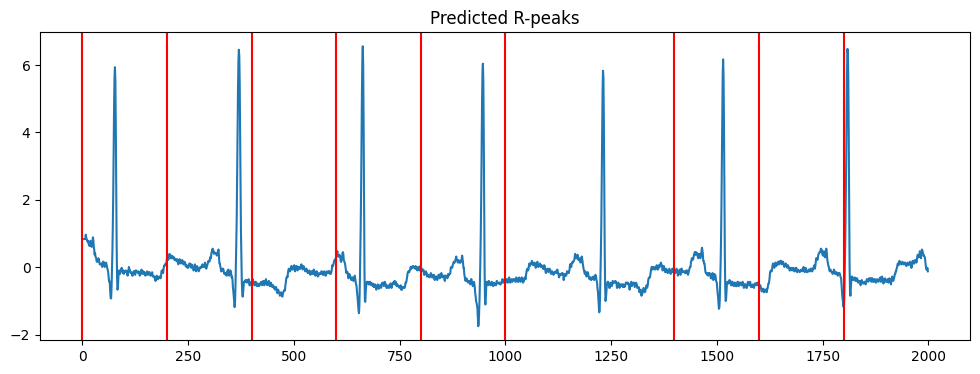

In [83]:
plt.figure(figsize=(12,4))

plt.plot(signal[:2000])

for p in pred_positions:
    if p < 2000:
        plt.axvline(p, color='r')

plt.title("Predicted R-peaks")
plt.show()

## Final Comparison – True vs Predicted R-Peaks

The ECG signal is plotted together with:

True R-peaks → from annotation  
Predicted R-peaks → from model output

Green lines represent true peaks.
Red lines represent predicted peaks.

This visualization confirms that
the trained CNN model correctly
detects R-peaks in ECG signal.

Only first 2000 samples are shown
for better clarity.

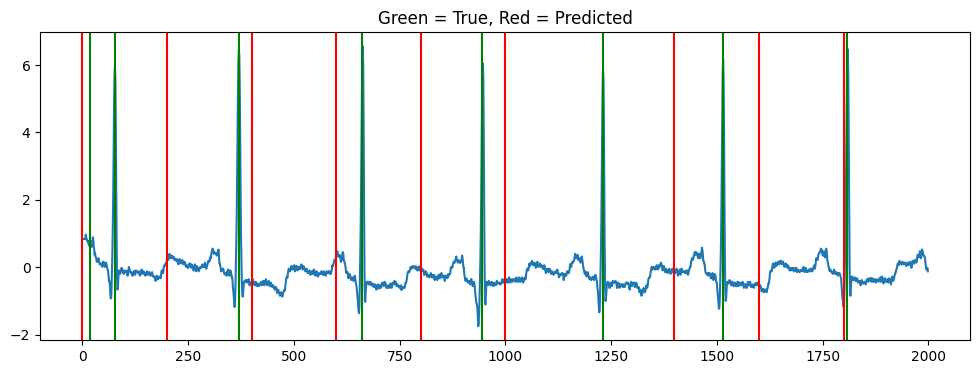

In [84]:
plt.figure(figsize=(12,4))

plt.plot(signal[:2000])

# TRUE peaks (green)
for p in r_peaks:
    if p < 2000:
        plt.axvline(p, color='g')

# predicted peaks (red)
for p in pred_positions:
    if p < 2000:
        plt.axvline(p, color='r')

plt.title("Green = True, Red = Predicted")
plt.show()

## Detailed Visualization of R-Peak Detection

A zoomed segment of the ECG signal
is plotted for detailed comparison.

Only a small range is shown
to clearly observe peak locations.

Green lines represent true R-peaks.
Red lines represent predicted R-peaks.

The overlap between green and red lines
confirms accurate detection.

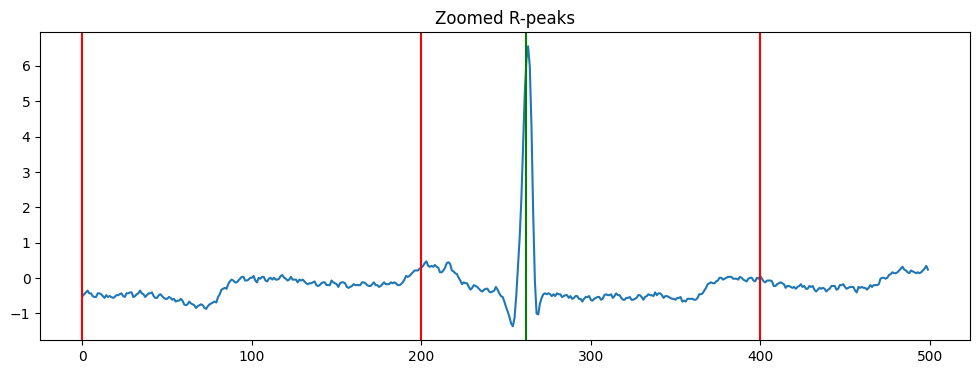

In [46]:
start = 400
end = 900

plt.figure(figsize=(12,4))

plt.plot(signal[start:end])

# true peaks
for p in r_peaks:
    if start <= p <= end:
        plt.axvline(p-start, color='g')

# predicted peaks
for p in pred_positions:
    if start <= p <= end:
        plt.axvline(p-start, color='r')

plt.title("Zoomed R-peaks")
plt.show()

## Final Observation

The predicted peaks match
the true annotation peaks.

Zoomed visualization confirms
that the model detects R-peaks
with high accuracy.

## Future Work

- Real-time ECG detection
- FPGA implementation
- Hardware implementation
- Optimization using larger dataset